# polynomial regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2  ->polynomial of degree 2

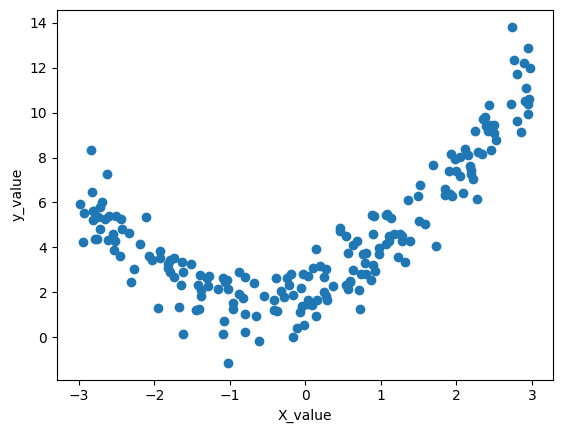

In [13]:
plt.scatter(X,y)
plt.xlabel("X_value")
plt.ylabel("y_value")
plt.show()

In [14]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
# Applying linear regression
lr = LinearRegression()

In [16]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.22382967675995524

X_train contain only-one feature X^1 but y_train (output) is due to X^0,X^1,X^3

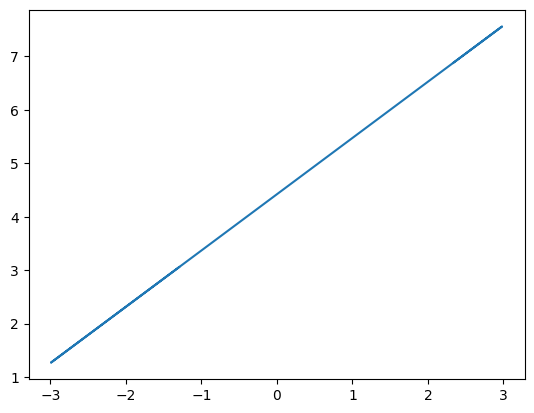

In [25]:
X_train   # it contain only one feature X^1
lr.predict(X_train)  
plt.plot(X_train,lr.predict(X_train))

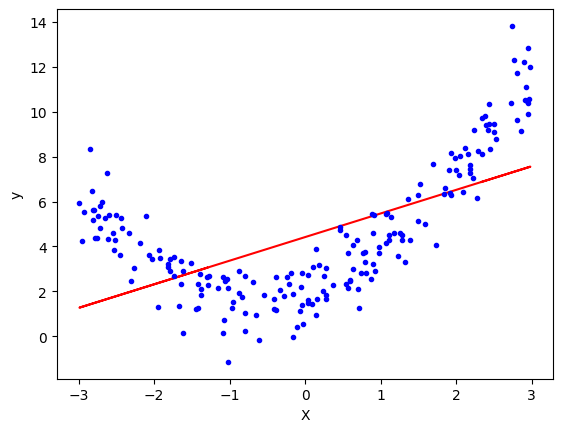

In [26]:
# ploting regression line and data
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

->its under fitting problem becaue we are using linaer regression

In [27]:
# Applying Polynomial Linear Regression
# degree 2
# including bias feature
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [31]:
X_train_trans  # it contain x^0,X^1,X^2 columns now input feature has every col on whict output id predicted

array([[ 1.00000000e+00, -1.29592746e+00,  1.67942798e+00],
       [ 1.00000000e+00, -1.44615829e+00,  2.09137379e+00],
       [ 1.00000000e+00,  9.19990844e-02,  8.46383153e-03],
       [ 1.00000000e+00, -2.26383980e+00,  5.12497064e+00],
       [ 1.00000000e+00, -1.02215518e+00,  1.04480122e+00],
       [ 1.00000000e+00,  1.73311371e+00,  3.00368313e+00],
       [ 1.00000000e+00, -2.94841155e+00,  8.69313067e+00],
       [ 1.00000000e+00,  2.18763916e+00,  4.78576508e+00],
       [ 1.00000000e+00,  1.25732247e+00,  1.58085981e+00],
       [ 1.00000000e+00, -2.11306507e+00,  4.46504401e+00],
       [ 1.00000000e+00, -3.79633125e-01,  1.44121310e-01],
       [ 1.00000000e+00,  2.79983704e+00,  7.83908746e+00],
       [ 1.00000000e+00,  2.43494389e+00,  5.92895176e+00],
       [ 1.00000000e+00,  2.90963149e+00,  8.46595540e+00],
       [ 1.00000000e+00,  7.05798353e-01,  4.98151315e-01],
       [ 1.00000000e+00,  2.45351504e+00,  6.01973604e+00],
       [ 1.00000000e+00,  5.38962873e-01

In [32]:
print(X_train[0])
print(X_train_trans[0])

[-1.29592746]
[ 1.         -1.29592746  1.67942798]


In [33]:
for i in X_train_trans:
    print(i)

[ 1.         -1.29592746  1.67942798]
[ 1.         -1.44615829  2.09137379]
[1.         0.09199908 0.00846383]
[ 1.         -2.2638398   5.12497064]
[ 1.         -1.02215518  1.04480122]
[1.         1.73311371 3.00368313]
[ 1.         -2.94841155  8.69313067]
[1.         2.18763916 4.78576508]
[1.         1.25732247 1.58085981]
[ 1.         -2.11306507  4.46504401]
[ 1.         -0.37963313  0.14412131]
[1.         2.79983704 7.83908746]
[1.         2.43494389 5.92895176]
[1.         2.90963149 8.4659554 ]
[1.         0.70579835 0.49815132]
[1.         2.45351504 6.01973604]
[1.         0.53896287 0.29048098]
[1.         1.91836976 3.68014252]
[ 1.         -0.2837095   0.08049108]
[1.         2.94566988 8.67697102]
[1.         0.18914617 0.03577627]
[ 1.         -0.96376379  0.92884065]
[ 1.         -0.61323296  0.37605467]
[ 1.         -2.33732765  5.46310052]
[1.         0.04122746 0.0016997 ]
[1.         0.59438521 0.35329378]
[1.         0.46163116 0.21310332]
[1.         0.24214216

In [50]:
# now applying linear regression on X_train_trans
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.9019081734780687

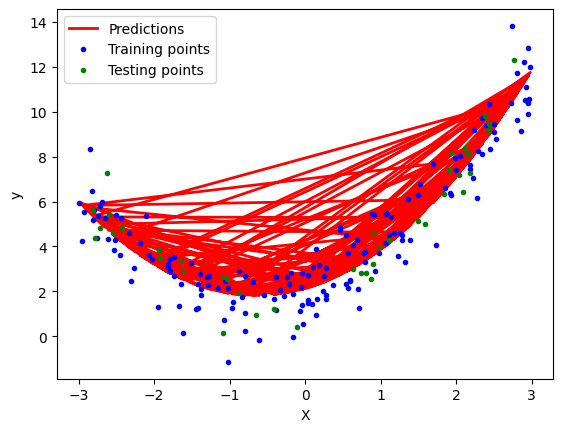

In [64]:
plt.plot(X_train,lr.predict(X_train_trans),"r-",linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [65]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.97524442 0.75632646]]
[2.12716664]


In [66]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

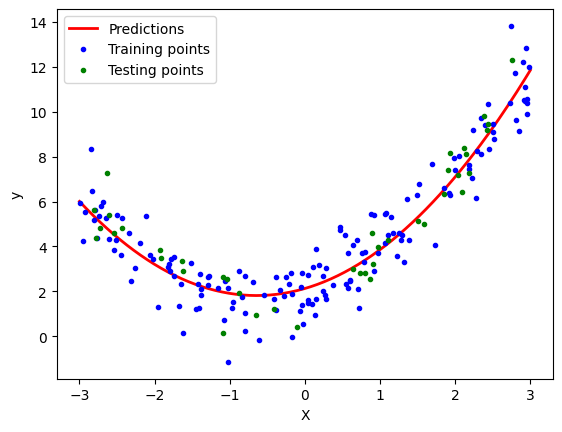

In [67]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

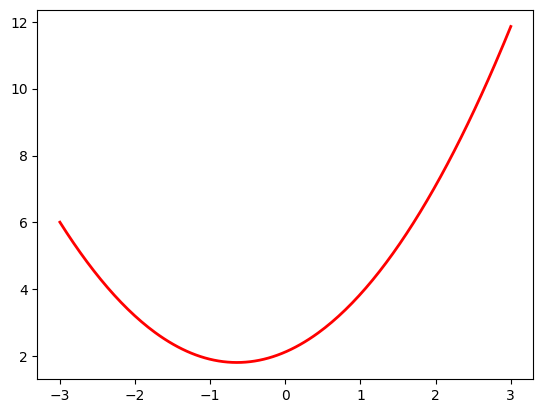

In [68]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")

In [75]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    # X_new_poly = poly.transform(X_new) this work is done by pipeline

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    # creating pipeline
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

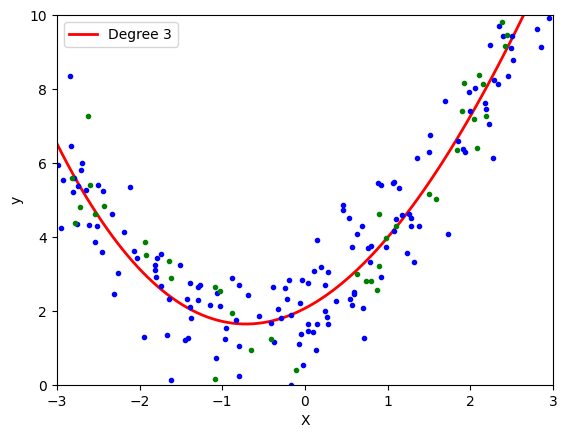

In [79]:
polynomial_regression(3)

-> degree increasing over fitting